# NLP Research Project: Fine-Grained Arabic Hate Speech Detection

This project focuses on detecting and classifying Arabic hate speech using transformer-based language models. The study uses the L-HSAB dataset, which contains Arabic social media posts labeled into three categories: Normal, Abusive, and Hate Speech.

The goal is to evaluate the effectiveness of modern Arabic transformer models in understanding linguistic patterns associated with offensive and hateful content and to analyze their classification performance.


Main parts:
1. Load L-HSAB train/test files
2. Arabic text preprocessing
3. Fine-tune Arabic transformer models: AraBERT, MARBERT, and Arabic-BERT
4. Evaluate using Accuracy, Precision, Recall, F1-score, Classification Report, and Confusion Matrix
5. Linguistic analysis and error analysis

In [1]:
# ============================================================
# 1. Install Required Libraries
# ============================================================
# Run this cell in Google Colab or Kaggle. A GPU is strongly recommended.

!pip install -q "numpy==1.26.4" "transformers==4.44.2" "accelerate==0.33.0" datasets evaluate scikit-learn pandas matplotlib
!pip install -q --upgrade numpy pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 40.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires 

In [3]:
!pip install -U --force-reinstall numpy scipy scikit-learn pandas

  Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.5 MB/s eta 0:00:00
  Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
Using cached numpy-2.4.6-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 43.3 MB/s eta 0:00:00
Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 454.8/454.8 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 17.9 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolct

In [1]:
# ============================================================
# 2. Imports and Environment Check
# ============================================================

import os
import re
import inspect
import random
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: Training transformers without GPU will be slow.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# ============================================================
# 3. Configuration
# ============================================================

TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"
TEXT_COLUMN = "Tweet"
LABEL_COLUMN = "Class"

# Use cleaned Arabic text for the model input.
# Change to False only if you want to train on raw tweets.
USE_CLEAN_TEXT = True

MAX_LENGTH = 128
VALIDATION_SIZE = 0.15
NUM_EPOCHS = 3
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

# These models match the proposal focus on Arabic transformers.
# Arabic-BERT is included but can be commented out if runtime is limited.
MODEL_CHECKPOINTS = {
    "AraBERT": "aubmindlab/bert-base-arabertv02",
    "MARBERT": "UBC-NLP/MARBERT",
    "Arabic-BERT": "asafaya/bert-base-arabic"
}

OUTPUT_RESULTS_FILE = "transformer_only_results.csv"
OUTPUT_ERRORS_FILE = "transformer_error_analysis.csv"

In [3]:
# ============================================================
# 4. Arabic Text Cleaning
# ============================================================
# The proposal requires cleaning usernames, links, emojis, repeated letters,
# punctuation, and unnecessary symbols, while avoiding over-cleaning.

def clean_arabic_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove usernames
    text = re.sub(r"@\w+", " ", text)

    # Keep hashtag content but remove the # symbol
    text = text.replace("#", " ")

    # Normalize common Arabic letter variations
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)

    # Remove Arabic diacritics
    text = re.sub(r"[ً-ٰٟ]", "", text)

    # Reduce repeated letters: حلوووو -> حلو
    text = re.sub(r"(.){2,}", r"", text)

    # Remove emojis and non-Arabic/non-space characters
    text = re.sub(r"[^؀-ۿ\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [5]:
# ============================================================
# 5. Load and Prepare Dataset
# ============================================================

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

required_columns = {TEXT_COLUMN, LABEL_COLUMN}
for name, df in [("train", train_df), ("test", test_df)]:
    missing = required_columns - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in {name}.csv: {missing}. Available columns: {list(df.columns)}")

train_df = train_df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN]).copy()
test_df = test_df.dropna(subset=[TEXT_COLUMN, LABEL_COLUMN]).copy()

train_df["clean_text"] = train_df[TEXT_COLUMN].apply(clean_arabic_text)
test_df["clean_text"] = test_df[TEXT_COLUMN].apply(clean_arabic_text)

# Remove empty rows after cleaning
text_source_col = "clean_text" if USE_CLEAN_TEXT else TEXT_COLUMN
train_df = train_df[train_df[text_source_col].astype(str).str.strip() != ""].copy()
test_df = test_df[test_df[text_source_col].astype(str).str.strip() != ""].copy()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train label distribution:")
print(train_df[LABEL_COLUMN].value_counts())
print("Test label distribution:")
print(test_df[LABEL_COLUMN].value_counts())

Train shape: (4675, 3)
Test shape: (1170, 3)
Train label distribution:
Class
normal     2919
abusive    1382
hate        374
Name: count, dtype: int64
Test label distribution:
Class
normal     730
abusive    346
hate        94
Name: count, dtype: int64


In [6]:
# ============================================================
# 6. Label Encoding
# ============================================================
# Automatically builds label2id/id2label from the training labels.
# This works for L-HSAB labels such as normal, abusive, hate.

labels = sorted(train_df[LABEL_COLUMN].astype(str).unique().tolist())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}

print("label2id:", label2id)
print("id2label:", id2label)

train_data = pd.DataFrame({
    "text": train_df[text_source_col].astype(str),
    "label": train_df[LABEL_COLUMN].astype(str).map(label2id)
})

test_data = pd.DataFrame({
    "text": test_df[text_source_col].astype(str),
    "label": test_df[LABEL_COLUMN].astype(str).map(label2id)
})

train_data = train_data.dropna(subset=["text", "label"]).copy()
test_data = test_data.dropna(subset=["text", "label"]).copy()
train_data["label"] = train_data["label"].astype(int)
test_data["label"] = test_data["label"].astype(int)

tr_df, val_df = train_test_split(
    train_data,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=train_data["label"]
)

print("Training examples:", len(tr_df))
print("Validation examples:", len(val_df))
print("Final test examples:", len(test_data))

label2id: {'abusive': 0, 'hate': 1, 'normal': 2}
id2label: {0: 'abusive', 1: 'hate', 2: 'normal'}
Training examples: 3973
Validation examples: 702
Final test examples: 1170


In [7]:
# ============================================================
# 7. Class Weights for Imbalanced Data
# ============================================================
# Hate speech datasets are usually imbalanced, so weighted loss helps minority classes.

class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(label2id.values())),
    y=tr_df["label"].values
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float)

print("Class weights:")
for idx, weight in enumerate(class_weights_np):
    print(f"{id2label[idx]}: {weight:.4f}")

Class weights:
abusive: 1.1281
hate: 4.1646
normal: 0.5338


In [8]:
# ============================================================
# 8. Metrics Function
# ============================================================

def compute_transformer_metrics(eval_pred):
    logits, labels_true = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels_true,
        predictions,
        average="macro",
        zero_division=0
    )
    accuracy = accuracy_score(labels_true, predictions)

    return {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

In [9]:
# ============================================================
# 9. Weighted Trainer
# ============================================================

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels_batch = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device) if self.class_weights is not None else None
        )
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels_batch.view(-1))

        return (loss, outputs) if return_outputs else loss

In [10]:
# ============================================================
# 10. TrainingArguments Helper
# ============================================================
# Keeps the notebook compatible with different Transformers versions.

def build_training_args(output_dir, experiment_name):
    base_args = {
        "output_dir": output_dir,
        "save_strategy": "no",
        "save_safetensors": False,
        "learning_rate": LEARNING_RATE,
        "per_device_train_batch_size": TRAIN_BATCH_SIZE,
        "per_device_eval_batch_size": EVAL_BATCH_SIZE,
        "num_train_epochs": NUM_EPOCHS,
        "weight_decay": WEIGHT_DECAY,
        "logging_dir": f"./logs_{experiment_name}",
        "logging_steps": 50,
        "load_best_model_at_end": False,
        "metric_for_best_model": "macro_f1",
        "greater_is_better": True,
        "report_to": "none",
        "seed": SEED,
    }

    signature_params = inspect.signature(TrainingArguments.__init__).parameters
    if "eval_strategy" in signature_params:
        base_args["eval_strategy"] = "epoch"
    else:
        base_args["evaluation_strategy"] = "epoch"

    return TrainingArguments(**base_args)

In [11]:
# ============================================================
# 11. Main Transformer Experiment Function
# ============================================================

transformer_predictions = {}

def tokenize_dataset(dataframe, tokenizer):
    dataset = Dataset.from_pandas(dataframe[["text", "label"]], preserve_index=False)

    def tokenize_function(batch):
        return tokenizer(
            batch["text"],
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH
        )

    dataset = dataset.map(tokenize_function, batched=True)
    dataset = dataset.rename_column("label", "labels")
    dataset = dataset.remove_columns(["text"])
    dataset.set_format("torch")
    return dataset


def run_transformer_experiment(experiment_name, model_checkpoint):
    print("=" * 90)
    print(f"Running: {experiment_name}")
    print(f"Checkpoint: {model_checkpoint}")
    print("=" * 90)

    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

    train_dataset = tokenize_dataset(tr_df, tokenizer)
    val_dataset = tokenize_dataset(val_df, tokenizer)
    final_test_dataset = tokenize_dataset(test_data, tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id
    )

    training_args = build_training_args(
        output_dir=f"./results_{experiment_name}",
        experiment_name=experiment_name
    )

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_transformer_metrics,
        class_weights=class_weights
    )

    trainer.train()

    print("Validation Results:")
    val_results = trainer.evaluate(eval_dataset=val_dataset)
    print(val_results)

    print("Final Test Results:")
    test_results = trainer.evaluate(eval_dataset=final_test_dataset)
    print(test_results)

    predictions_output = trainer.predict(final_test_dataset)
    y_pred = np.argmax(predictions_output.predictions, axis=-1)
    y_true = predictions_output.label_ids
    target_names = [id2label[i] for i in range(len(id2label))]

    print("Classification Report on test.csv:")
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

    print("Confusion Matrix on test.csv:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(xticks_rotation=45)
    plt.title(f"Confusion Matrix - {experiment_name}")
    plt.show()

    transformer_predictions[experiment_name] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "texts": test_data["text"].tolist()
    }

    return {
        "Model": experiment_name,
        "Checkpoint": model_checkpoint,
        "Accuracy": test_results["eval_accuracy"],
        "Precision": test_results["eval_macro_precision"],
        "Recall": test_results["eval_macro_recall"],
        "F1-score": test_results["eval_macro_f1"]
    }

Running: AraBERT
Checkpoint: aubmindlab/bert-base-arabertv02


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.755300,0.704951,0.747863,0.628011,0.682923,0.640314
2,0.562400,0.680252,0.806268,0.701169,0.713415,0.706896
3,0.359400,0.738781,0.811966,0.716105,0.739891,0.726867


Validation Results:


{'eval_loss': 0.7387811541557312, 'eval_accuracy': 0.811965811965812, 'eval_macro_precision': 0.7161051822761034, 'eval_macro_recall': 0.7398911970829779, 'eval_macro_f1': 0.7268668992676156, 'eval_runtime': 6.3081, 'eval_samples_per_second': 111.285, 'eval_steps_per_second': 6.975, 'epoch': 3.0}
Final Test Results:
{'eval_loss': 0.6859155893325806, 'eval_accuracy': 0.8162393162393162, 'eval_macro_precision': 0.7037227612793623, 'eval_macro_recall': 0.7259523139638646, 'eval_macro_f1': 0.7132352644673756, 'eval_runtime': 10.5617, 'eval_samples_per_second': 110.777, 'eval_steps_per_second': 7.006, 'epoch': 3.0}
Classification Report on test.csv:
              precision    recall  f1-score   support

     abusive       0.75      0.74      0.74       346
        hate       0.46      0.55      0.50        94
      normal       0.91      0.89      0.90       730

    accuracy                           0.82      1170
   macro avg       0.70      0.73      0.71      1170
weighted avg       0.

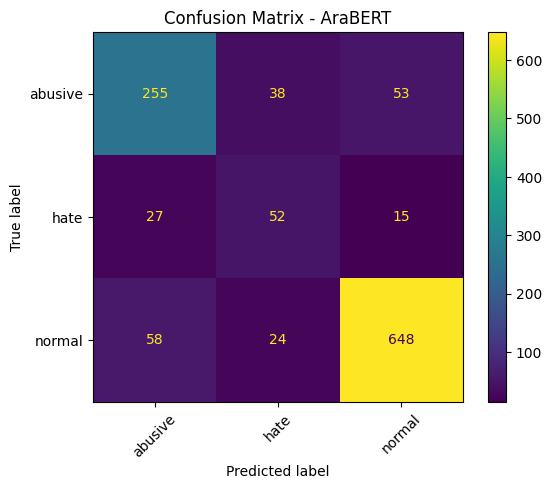

Running: MARBERT
Checkpoint: UBC-NLP/MARBERT


tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/654M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.709000,0.609066,0.836182,0.721322,0.758304,0.727868
2,0.363600,0.711082,0.850427,0.747026,0.771379,0.758042
3,0.162600,0.857519,0.864672,0.764347,0.776323,0.770075


Validation Results:


{'eval_loss': 0.8575190901756287, 'eval_accuracy': 0.8646723646723646, 'eval_macro_precision': 0.764347397396847, 'eval_macro_recall': 0.7763226119390502, 'eval_macro_f1': 0.770075245779699, 'eval_runtime': 6.0222, 'eval_samples_per_second': 116.569, 'eval_steps_per_second': 7.306, 'epoch': 3.0}
Final Test Results:
{'eval_loss': 0.8253443241119385, 'eval_accuracy': 0.8700854700854701, 'eval_macro_precision': 0.8048755754084881, 'eval_macro_recall': 0.7873970131786067, 'eval_macro_f1': 0.7948814041788804, 'eval_runtime': 10.0652, 'eval_samples_per_second': 116.242, 'eval_steps_per_second': 7.352, 'epoch': 3.0}
Classification Report on test.csv:
              precision    recall  f1-score   support

     abusive       0.79      0.84      0.81       346
        hate       0.70      0.61      0.65        94
      normal       0.93      0.92      0.93       730

    accuracy                           0.87      1170
   macro avg       0.80      0.79      0.79      1170
weighted avg       0.8

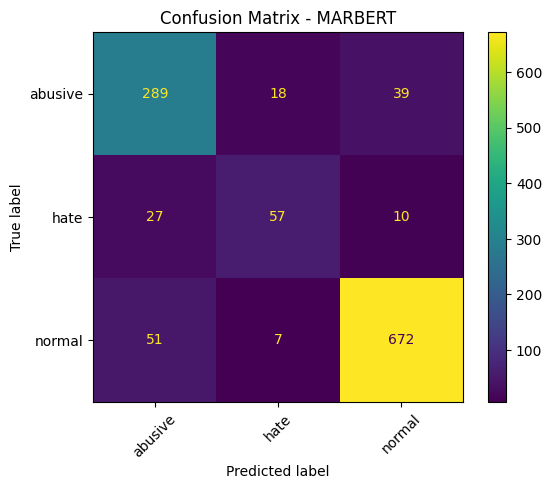

Running: Arabic-BERT
Checkpoint: asafaya/bert-base-arabic


tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/491 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at asafaya/bert-base-arabic and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Macro Precision,Macro Recall,Macro F1
1,0.786400,0.750576,0.712251,0.609269,0.673581,0.615286
2,0.477800,0.782035,0.790598,0.684952,0.725110,0.701080
3,0.242900,0.928449,0.801994,0.704168,0.723198,0.712847


Validation Results:


{'eval_loss': 0.9284493327140808, 'eval_accuracy': 0.801994301994302, 'eval_macro_precision': 0.7041675207843093, 'eval_macro_recall': 0.7231975596701624, 'eval_macro_f1': 0.7128467536362274, 'eval_runtime': 6.2973, 'eval_samples_per_second': 111.476, 'eval_steps_per_second': 6.987, 'epoch': 3.0}
Final Test Results:
{'eval_loss': 0.7973935604095459, 'eval_accuracy': 0.8017094017094017, 'eval_macro_precision': 0.7050759452597344, 'eval_macro_recall': 0.7315612102955654, 'eval_macro_f1': 0.7169424109155752, 'eval_runtime': 10.5222, 'eval_samples_per_second': 111.193, 'eval_steps_per_second': 7.033, 'epoch': 3.0}
Classification Report on test.csv:
              precision    recall  f1-score   support

     abusive       0.70      0.74      0.72       346
        hate       0.51      0.60      0.55        94
      normal       0.90      0.86      0.88       730

    accuracy                           0.80      1170
   macro avg       0.71      0.73      0.72      1170
weighted avg       0.

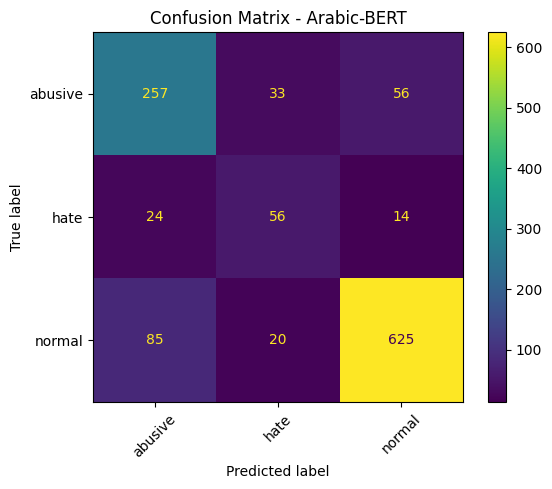

Final Transformer-only Results:
         Model                       Checkpoint   Accuracy  Precision  \
1      MARBERT                  UBC-NLP/MARBERT  87.008547  80.487558   
2  Arabic-BERT         asafaya/bert-base-arabic  80.170940  70.507595   
0      AraBERT  aubmindlab/bert-base-arabertv02  81.623932  70.372276   

      Recall   F1-score  
1  78.739701  79.488140  
2  73.156121  71.694241  
0  72.595231  71.323526  
Saved results to: transformer_only_results.csv
Best Transformer Model Based on Macro F1-score:
Model                 MARBERT
Checkpoint    UBC-NLP/MARBERT
Accuracy            87.008547
Precision           80.487558
Recall              78.739701
F1-score             79.48814
Name: 1, dtype: object


In [12]:
# ============================================================
# 12. Run Transformer Experiments
# ============================================================
# This is the main experiment section. It trains only transformer models.

results = []

for experiment_name, checkpoint in MODEL_CHECKPOINTS.items():
    result = run_transformer_experiment(experiment_name, checkpoint)
    results.append(result)

results_df = pd.DataFrame(results)
results_percent = results_df.copy()
for col in ["Accuracy", "Precision", "Recall", "F1-score"]:
    results_percent[col] = results_percent[col] * 100

results_percent = results_percent.sort_values(by="F1-score", ascending=False)
print("Final Transformer-only Results:")
print(results_percent)

results_percent.to_csv(OUTPUT_RESULTS_FILE, index=False)
print(f"Saved results to: {OUTPUT_RESULTS_FILE}")

best_model_row = results_percent.iloc[0]
print("Best Transformer Model Based on Macro F1-score:")
print(best_model_row)

# Linguistic Analysis

This section supports the proposal requirement to explain the language patterns in the dataset and the errors made by the transformer model.

In [13]:
# ============================================================
# 13. Common Words per Class
# ============================================================

arabic_stopwords = set([
    "في", "من", "على", "و", "يا", "ما", "لا", "انا", "ان", "انك", "الى", "عن",
    "هو", "هي", "هذا", "هذه", "ذلك", "كل", "كان", "كانت", "مع", "كما", "قد",
    "هل", "او", "اي", "لما", "لو", "انت", "انتي", "انه", "هم", "هن", "ثم", "بس",
    "اللي", "الى", "إلى", "فيه", "فيها", "علي", "عليه", "عليها"
])

def get_top_words_by_class(dataframe, class_name, text_col="clean_text", top_n=20):
    texts = dataframe[dataframe[LABEL_COLUMN].astype(str) == str(class_name)][text_col].dropna().astype(str)
    words = []

    for text in texts:
        for word in text.split():
            if len(word) > 2 and word not in arabic_stopwords:
                words.append(word)

    return Counter(words).most_common(top_n)

for class_name in labels:
    print("=" * 80)
    print(f"Top words in class: {class_name}")
    print("=" * 80)
    print(get_top_words_by_class(train_df, class_name, text_col="clean_text", top_n=20))
    print()

Top words in class: abusive
[('هوا', 151), ('كول', 148), ('جبران', 100), ('باسيل', 95), ('كلب', 92), ('الله', 78), ('حمار', 55), ('خراس', 53), ('روح', 48), ('ولا', 48), ('وهاب', 48), ('ابن', 47), ('بلا', 47), ('اذا', 47), ('واحد', 46), ('عليك', 44), ('ابو', 42), ('هيك', 42), ('يلعن', 41), ('الي', 40)]

Top words in class: hate
[('كلب', 40), ('الله', 35), ('كلاب', 33), ('لبنان', 22), ('قطر', 19), ('متل', 18), ('ولا', 17), ('الي', 17), ('انتو', 16), ('حزب', 16), ('جبران', 16), ('باسيل', 16), ('العرب', 14), ('درزي', 14), ('هيك', 14), ('سوري', 14), ('ابن', 14), ('اذا', 13), ('ولاك', 12), ('ايران', 12)]

Top words in class: normal
[('جبران', 751), ('باسيل', 744), ('الله', 177), ('لبنان', 175), ('الي', 163), ('الوزير', 122), ('اذا', 118), ('ولا', 115), ('وهاب', 106), ('انو', 97), ('قطر', 91), ('مين', 87), ('وزير', 86), ('يلي', 79), ('سوريا', 77), ('اسراييل', 76), ('الرييس', 73), ('القمه', 68), ('عون', 68), ('حدا', 66)]



In [14]:
# ============================================================
# 14. Error Analysis for the Best Transformer Model
# ============================================================

if len(transformer_predictions) > 0:
    best_transformer_name = results_percent.iloc[0]["Model"]
    preds_info = transformer_predictions[best_transformer_name]

    y_true = preds_info["y_true"]
    y_pred = preds_info["y_pred"]
    texts = preds_info["texts"]

    error_rows = []
    for text, true_id, pred_id in zip(texts, y_true, y_pred):
        if int(true_id) != int(pred_id):
            error_rows.append({
                "Text": text,
                "True Label": id2label[int(true_id)],
                "Predicted Label": id2label[int(pred_id)]
            })

    error_df = pd.DataFrame(error_rows)

    print("Best transformer for error analysis:", best_transformer_name)
    print("Number of errors:", len(error_df))
    print("Sample errors:")
    display(error_df.head(20))

    error_df.to_csv(OUTPUT_ERRORS_FILE, index=False)
    print(f"Saved error analysis to: {OUTPUT_ERRORS_FILE}")
else:
    print("No transformer predictions found. Run the transformer experiments first.")

Best transformer for error analysis: MARBERT
Number of errors: 152
Sample errors:


,Text,True Label,Predicted Label
0,يا حبيبي سعد الحريري باع دم بيو كرمال يعمر سور...,hate,abusive
1,هو وغيره من العملاء ممن يسمون انفسهم زعماء للع...,normal,hate
2,كان زهايمر ياتي في عمر متاخر بس ها الزمن بلش ا...,abusive,normal
3,الاناء ينضح بما فيه عثمان رجل دوله وانت قاتل م...,abusive,normal
4,يريد اعمار سوريا والزباله تطمره في بيروت,normal,abusive
5,يتيم المجد يدفع لكم ملياردولار واخرتها تحطون ص...,normal,abusive
6,الروس المفروض ينشهروا بالوقاحه مو بالڤودكا,hate,abusive
7,كذبك يا ايوب بكفي كذب وافتراء بحق جبران باسيل,normal,abusive
8,مياومو الاعلام وشايعاتكم ما رح تغبروا عل صرماي...,hate,abusive
9,وافسم بالله انك كبير المنافقين هي قطر اللي دمر...,normal,abusive


Saved error analysis to: transformer_error_analysis.csv


In [15]:
# ============================================================
# 15. Save Cleaned Dataset Copies
# ============================================================
# These files help document exactly what text was used in the transformer experiments.

train_df.to_csv("cleaned_train_for_transformers.csv", index=False)
test_df.to_csv("cleaned_test_for_transformers.csv", index=False)

print("Saved cleaned_train_for_transformers.csv")
print("Saved cleaned_test_for_transformers.csv")

Saved cleaned_train_for_transformers.csv
Saved cleaned_test_for_transformers.csv
